<div align="center">
  <h1>Predicting Customer Ratings of Beauty Products</h1>
  <h5>Yanran Qiu (yanranq@uchicago.edu)</h5>
</div>

The Google Colab link of this notebook: https://colab.research.google.com/drive/1GZKTPo9s0nPxvpuaIPkwR6ObgGZcexTO?authuser=1

# 1. Research Questions

1. Can customer review text be used to predict whether a review corresponds to a high or low product rating?
- Supervised machine learning task & classification task
    1. Logistic Regression Model (section 5.1)
    2. Decision Tree Model (section 5.2.1)
    3. Random Forest Model (section 5.2.2)
2. What are the distinct rating dimensions that customers emphasize when reviewing beauty products?
- Unsupervised machine learning task & topic modeling task
    - BERTopic (section 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# scientific calculation packages
import numpy as np
import pandas as pd
from pprint import pprint
from collections import Counter

# visualization packages
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# natural language processing packages
import re
from tqdm import tqdm
import re, string
from bs4 import BeautifulSoup


# machine learning packages
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 2. Data Preparation and Overview

The data source for this project is the [Amazon Reviews 2023 dataset](https://amazon-reviews-2023.github.io/) collected in 2023, hosted by UC San Diego. The original dataset has 571.54M reviews ranging from May 1996 to September 2023. I focus exclusively on reviews posted in 2023. The purposes are 1) ensuring computational feasibility by reducing the sample size to a manageable yet substantial scale, 2) optimizing the classifier for comtemporary review analysis.

## 2.1 Data extraction & merge

In [ ]:
# Extract data in 2023 from the original review database
df_complete = pd.read_json('All_Beauty.jsonl', lines=True)
df_review2023 = df_complete.loc[
    df_complete['timestamp'].dt.year == 2023,
    ['rating', 'title', 'text', 'parent_asin', 'timestamp', 'verified_purchase']
    ].copy()

# Examine the earliest and latest timestamp
print(f"Earliest: {df_review2023['timestamp'].min()}")
print(f"Latest: {df_review2023['timestamp'].max()}")

Earliest: 2023-01-01 00:30:35.204000
Latest: 2023-09-09 00:39:36.666000


In [ ]:
# Join the product name from the metadata database
meta = pd.read_json("meta_All_Beauty.jsonl", lines=True)
meta = meta[["parent_asin", "title"]].copy()

df_beauty2023 = df_review2023.merge(
    meta.rename(columns={'title':'product_title'}),
    on="parent_asin",
    how="left"
)
df_beauty2023.head()

,rating,title,text,parent_asin,timestamp,verified_purchase,product_title
0,1,halo hair extensions,"This halo hair extension is simply put, garbag...",B0BFR5WF1R,2023-02-08 03:18:53.052,True,Halo Hair Extensions Thick Invisible Wire Hair...
1,1,Crap,These look and fit BAD.<br />Fake looking.<br ...,B0BL3HSBZB,2023-01-22 18:16:38.983,True,"JPSR Fake Teeth, 2 PCS Dentures Teeth for Wome..."
2,4,Good...But Not My Favorite,"Despite having a thick-ish, creamy consistency...",B0BXB4J297,2023-03-11 21:45:21.367,False,Moroccanoil Color Care Conditioner
3,4,Nice Formula!,Very “rusty” color.,B07TT8JK51,2023-01-05 12:54:25.267,True,Charlotte Tilbury Hot Lips 2 Viva La Vergara L...
4,1,"over priced, over hyped, doesn't work",Chose warm vanilla and the fragrance is wonder...,B09XBSDCXP,2023-02-12 11:49:15.202,True,Lume Solid Deodorant Stick - Whole Body Deodor...


In [ ]:
# Store the final dataset in a csv file
df_beauty2023.to_csv('Product Review_beauty2023.csv', index=False)

## 2.2 Data overview and description

In [ ]:
# read the dataframe and get an overview
df_beauty2023 = pd.read_csv('Product Review_beauty2023.csv')
df_beauty2023.head()

,rating,title,text,parent_asin,timestamp,verified_purchase,product_title
0,1,halo hair extensions,"This halo hair extension is simply put, garbag...",B0BFR5WF1R,2023-02-08 03:18:53.052,True,Halo Hair Extensions Thick Invisible Wire Hair...
1,1,Crap,These look and fit BAD.<br />Fake looking.<br ...,B0BL3HSBZB,2023-01-22 18:16:38.983,True,"JPSR Fake Teeth, 2 PCS Dentures Teeth for Wome..."
2,4,Good...But Not My Favorite,"Despite having a thick-ish, creamy consistency...",B0BXB4J297,2023-03-11 21:45:21.367,False,Moroccanoil Color Care Conditioner
3,4,Nice Formula!,Very “rusty” color.,B07TT8JK51,2023-01-05 12:54:25.267,True,Charlotte Tilbury Hot Lips 2 Viva La Vergara L...
4,1,"over priced, over hyped, doesn't work",Chose warm vanilla and the fragrance is wonder...,B09XBSDCXP,2023-02-12 11:49:15.202,True,Lume Solid Deodorant Stick - Whole Body Deodor...


In [ ]:
# check the shape of the data frame
df_beauty2023.shape

(14405, 7)

In [ ]:
df_beauty2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14405 entries, 0 to 14404
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rating             14405 non-null  int64 
 1   title              14402 non-null  object
 2   text               14404 non-null  object
 3   parent_asin        14405 non-null  object
 4   timestamp          14405 non-null  object
 5   verified_purchase  14405 non-null  bool  
 6   product_title      14403 non-null  object
dtypes: bool(1), int64(1), object(5)
memory usage: 689.4+ KB


In [ ]:
# numerical variable discription
df_beauty2023.describe()

,rating
count,14405.000000
mean,3.872128
std,1.562110
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
# the number of unique products
df_beauty2023['parent_asin'].nunique()

5397

In [ ]:
# time window
min_time = df_beauty2023['timestamp'].min()
max_time = df_beauty2023['timestamp'].max()

print(f"Earliest {min_time}")
print(f"Latest: {max_time}")

Earliest 2023-01-01 00:30:35.204
Latest: 2023-09-09 00:39:36.666


The merged dataset has 14405 samples and 7 features. Four of them are textual features:
- `title`: title of the review
- `text`: the review text
- `product_title`: the name of the product, 5397 unique products
- `parent_asin`: the primary identifier code for the product, representing the core product listing, 5397 unique products

One numerical feature:
- `rating` (1-5): the corresponding rating of the product from the review
    - standard deviation: 1.562
    - mean: 3.872
    - median: 5

One categorical feature:
- `verified_purchase`: 2 categories
    - True: the purchase of the review is verified
    - False: the purchase of the review is not verified

One timestamp feature:
- `timestamp`: the date and time at which the review was posted, from Jan 1, 2023 to September 9, 2023.

## 2.3 Data cleaning

### 2.3.1 Missing values

In [ ]:
# check missing values
null_sum = df_beauty2023.isnull().sum()
null_sum

rating               0
title                3
text                 1
parent_asin          0
timestamp            0
verified_purchase    0
product_title        2
dtype: int64

Because the number of missing values are very small compared to the total 14405 samples, I choose to drop the rows with missing values：

In [ ]:
# drop missing values
df_beauty2023 = df_beauty2023.dropna()

In [ ]:
# check the remaining number of samples and columns
df_beauty2023.shape, df_beauty2023.columns

((14400, 7),
 Index(['rating', 'title', 'text', 'parent_asin', 'timestamp',
        'verified_purchase', 'product_title'],
       dtype='object'))

The sample size reduced from 14,405 to 14,400. Dropped 5 samples with missing values.

### 2.3.2 Remove duplicates

In [ ]:
# Drop duplicates
df_beauty2023 = df_beauty2023.drop_duplicates(keep="first")
df_beauty2023.shape

(14206, 7)

The number of samples reduced from 14,400 to 14,206. Dropped 194 duplicates.

### 2.3.3 Remove reviews without verified purchase

In [ ]:
df_beauty2023 = df_beauty2023[df_beauty2023['verified_purchase'] == True].copy()

In [ ]:
df_beauty2023.shape

(12647, 7)

The number of samples reduced from 14206 to 12647. Removed 1559 unverfied purchases.

## 2.4 Rating Relabelling and Undersampling

### 2.4.1 Create categorical labels for ratings

I relabel the numerical feature rating and transform it into a binary categorical feature. Ratings were binarized using 4 stars as the cutoff to maximize the discriminative power of the classifier. This is based on the consideration that 4 and 5-star reviews consistently convey positive endorsement, while 3-star reviews represent a neutral-to-negative shift, frequently highlighting product flaws.

In [ ]:
# check the distribution of 'rating'
df_beauty2023['rating'].describe()

count    12647.000000
mean         3.859334
std          1.586724
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

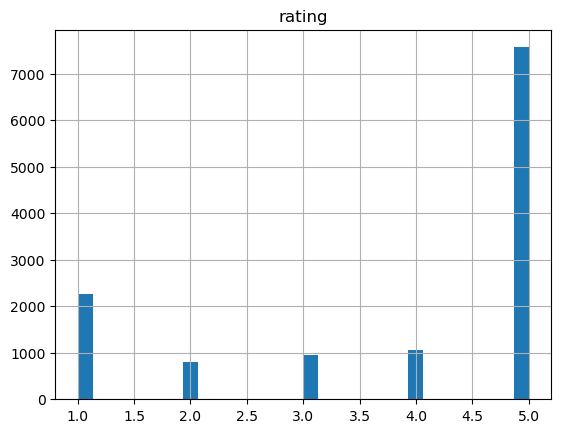

In [ ]:
df_beauty2023.hist(column='rating', bins=30)
plt.show()

In [ ]:
# create the label based on rating: rating 1-3 low, rating 4-5 high
df_beauty2023["cat_rating"] = np.where(
    df_beauty2023["rating"] >= 4,
    'high',
    'low'
    )

In [ ]:
# check the distribution of the target variable
df_beauty2023["cat_rating"].value_counts()

cat_rating
high    8623
low     4024
Name: count, dtype: int64

<Axes: xlabel='cat_rating'>

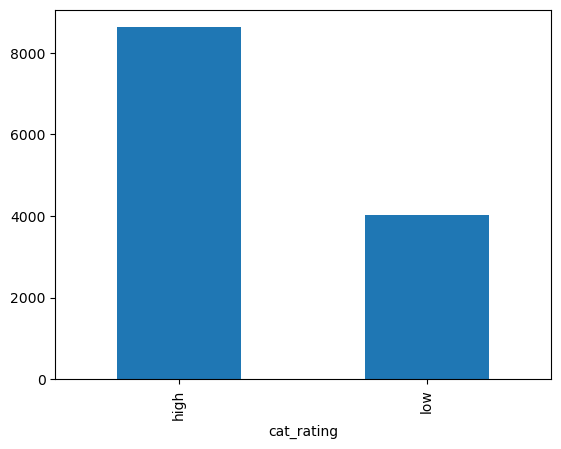

In [ ]:
df_beauty2023["cat_rating"].value_counts().plot(kind='bar')

Because the distribution of the target variable is imbalanced. Random undersampling should be performed on the high rating category.

### 2.4.2 Random undersampling

In [ ]:
# Devide the dataframe by rating categories
df_majority = df_beauty2023[df_beauty2023['cat_rating'] == 'high']
df_minority = df_beauty2023[df_beauty2023['cat_rating'] == 'low']

# check the number of the minority group
n_minority = len(df_minority)

# randomly choose the same number of samples from the majority group
df_majority_downsampled = df_majority.sample(
    n=n_minority,
    random_state=42
)

# merge the undersampled majority group with the minority group
df_balanced = pd.concat(
    [df_majority_downsampled, df_minority]
).sample(frac=1, random_state=42)

# check the final distribution
df_balanced["cat_rating"].value_counts()

cat_rating
high    4024
low     4024
Name: count, dtype: int64

# 3. Exploratory Data Analysis

## 3.1 Target variable

<Axes: xlabel='cat_rating'>

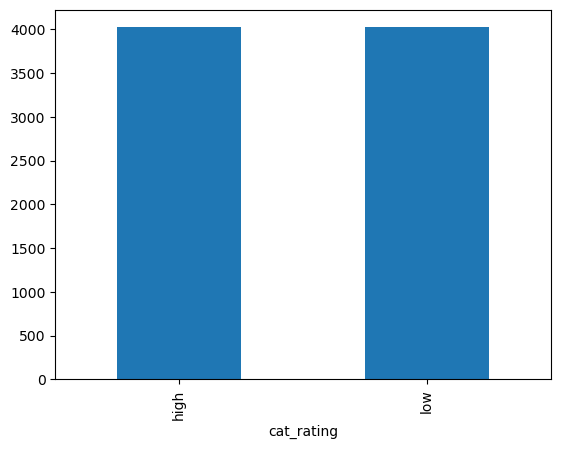

In [ ]:
df_balanced["cat_rating"].value_counts().plot(kind='bar')

After undersampling, the dataset is now equally distributed (balanced). Next, convert the category labels to binary values (1 for high rating, 0 for low rating).

In [ ]:
df_balanced['label'] = df_balanced['cat_rating'].map({'high':1,'low':0})
df_balanced.head()[['title', 'text', 'rating', 'cat_rating','label']]

,title,text,rating,cat_rating,label
0,Amber,Smells good one full dab is all you need,4,high,1
1,Awesome!,This eye liner stays on....about time!,5,high,1
2,Damaged items,Product came defective. The slip solution leak...,1,low,0
3,I wanted to love this!,This is nothing like the pictures. I needed a ...,3,low,0
4,Colors not accurate,"I like these bottles, but I got three pink and...",2,low,0


## 3.2 Feature variable

Check the length of the reviews:

In [ ]:
# merge the title and text of the review
df_balanced["review"] = df_balanced["title"] + " " + df_balanced["text"]

In [ ]:
# add a new column 'length' to the dataframe
df_balanced['length'] = df_balanced['review'].apply(len)
df_balanced['length'].describe()

count    8048.000000
mean      172.776963
std       173.149139
min         4.000000
25%        68.000000
50%       124.000000
75%       218.250000
max      3289.000000
Name: length, dtype: float64

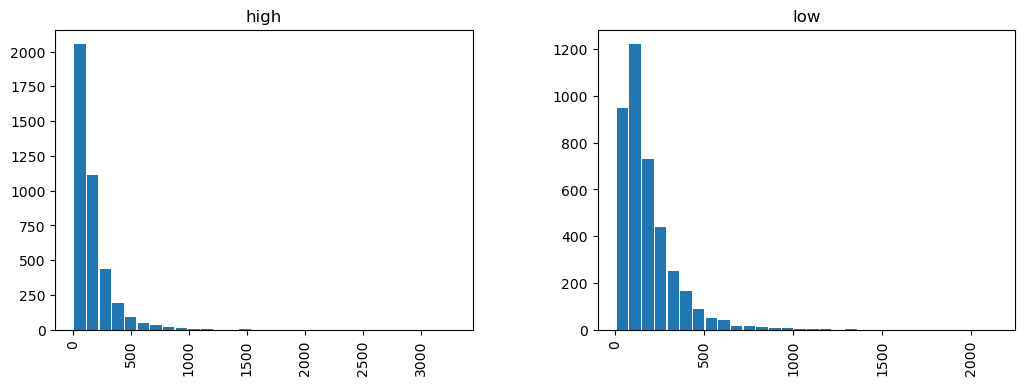

In [ ]:
# check the length distribution of positive and negative reviews
# x: length of reviews; y: number of reviews fall into each interval
df_balanced.hist(column='length', by='cat_rating',bins=30, figsize=(12,4),
             rwidth=0.9)
plt.show()

The distribution plot shows that there's no clear differences between high-rating and low-rating reviews in terms of length.

In [ ]:
# store the balanced dataset
df_balanced.to_csv('Product Review_beauty2023_balanced.csv', index=False)

# 4. Text Data Preprocessing and Representation

In [ ]:
df_balanced = pd.read_csv('Product Review_beauty2023_balanced.csv')

After browsing through the original review text, I conduct the following steps to clean the text data: expand contractions into normal words, remove html tags, non-alphabatic characters, url, punctuations, and shorten prolonged words, such as "sooooo":

In [ ]:
def decontracted(phrase):
    """
    Expand contractions into normal words
    """
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase) # prime
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)

    return phrase

def clean_text(df):
    """
    Clean the review texts
    """
    cleaned_review = []

    for review_text in tqdm(df['review']):

        # expand contractions
        review_text = decontracted(review_text)

        # remove html tags
        review_text = BeautifulSoup(review_text, 'lxml').get_text().strip() # re.sub(r'<.*?>', '', text)

        # remove non-alphabetic characters
        review_text = re.sub("[^a-zA-Z]"," ", review_text)

        # remove url
        review_text = re.sub(r'https?://\S+|www\.\S+', '', review_text)

        # remove punctutation !"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~`
        review_text = re.sub(r'(.)\1{2,}', r'\1\1', review_text)

        # shorten prolonged words (sooooo -> soo), keep two repeated characters to avoid transforming words like "look" to "lok"
        review_text = review_text.translate(str.maketrans('', '', string.punctuation))

        cleaned_review.append(review_text)

    return cleaned_review

In [ ]:
# clean reviews in the balanced dataset
df_balanced['cleaned_review'] = clean_text(df_balanced)

# put the cleaned data in a new dataframe
df_balanced.head()[['review', 'cleaned_review', 'cat_rating', 'label']]

100%|██████████| 8048/8048 [00:02<00:00, 2791.88it/s]


,review,cleaned_review,cat_rating,label
0,Amber Smells good one full dab is all you need,Amber Smells good one full dab is all you need,high,1
1,Awesome! This eye liner stays on....about time!,Awesome This eye liner stays on about time,high,1
2,Damaged items Product came defective. The slip...,Damaged items Product came defective The slip...,low,0
3,I wanted to love this! This is nothing like th...,I wanted to love this This is nothing like th...,low,0
4,"Colors not accurate I like these bottles, but ...",Colors not accurate I like these bottles but ...,low,0


In [ ]:
# store the cleaned data
df_balanced.to_csv("Product Review_beauty2023_cleaned.csv", index=False)

I choose to use tf-idf vectorizer to represent textual data:

In [ ]:
# read the cleaned dataset
df_cleaned = pd.read_csv("Product Review_beauty2023_cleaned.csv")

In [ ]:
# define stop words
stopwords= list(set(['product', 'item', 'amazon', 'buy', 'bought', 'purchase', 'purchased', 'use', 'used','thought', 'think', 'thinking' \
            'using', 'work', 'works', 'working', 'try', 'tried', 'got','br', 'the', 'i', 'me', 'my', 'myself', 'we', \
            'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', \
            'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", \
            'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', \
            'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', \
            'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', \
            'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', \
            'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', \
            'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
            'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
            's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
            've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
            "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
            "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
            'won', "won't", 'wouldn', "wouldn't"]))


In [ ]:
vectorizer_tfidf = TfidfVectorizer(lowercase=True, stop_words=stopwords, max_df=0.9, min_df=3, ngram_range=(1,1))
X = vectorizer_tfidf.fit_transform(df_cleaned.cleaned_review)

# check the shape of the represented text data
print("X.shape : ",X.shape)

X.shape :  (8048, 4101)


In [ ]:
# check the representation of the first example
X[0]

<1x4101 sparse matrix of type '<class 'numpy.float64'>'
	with 7 stored elements in Compressed Sparse Row format>

The first sample only have 7 valid features out of the totall 4101 textual features, which indicates that the data is very sparse.

In [ ]:
# define the target variable
y = df_cleaned.label.values

print("y.shape : ",y.shape)

y.shape :  (8048,)


# 5. Supervised Model Training

In [ ]:
indices = np.arange(df_cleaned.shape[0])

# split 30% testing data according to the index
train_idx, test_idx = train_test_split(
    indices, test_size=0.3, shuffle=True, random_state=42
)

print(f"Number of training examples: {len(train_idx)}")
print(f"Number of testing examples: {len(test_idx)}")

Number of training examples: 5633
Number of testing examples: 2415


In [ ]:
# define training, validation, and testing data according to the splitted index
X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Training data: X_train : {}, y_train : {}".format(X_train.shape, y_train.shape))
print("Testing data: X_test : {}, y_test : {}".format(X_test.shape, y_test.shape))

Training data: X_train : (5633, 4101), y_train : (5633,)
Testing data: X_test : (2415, 4101), y_test : (2415,)


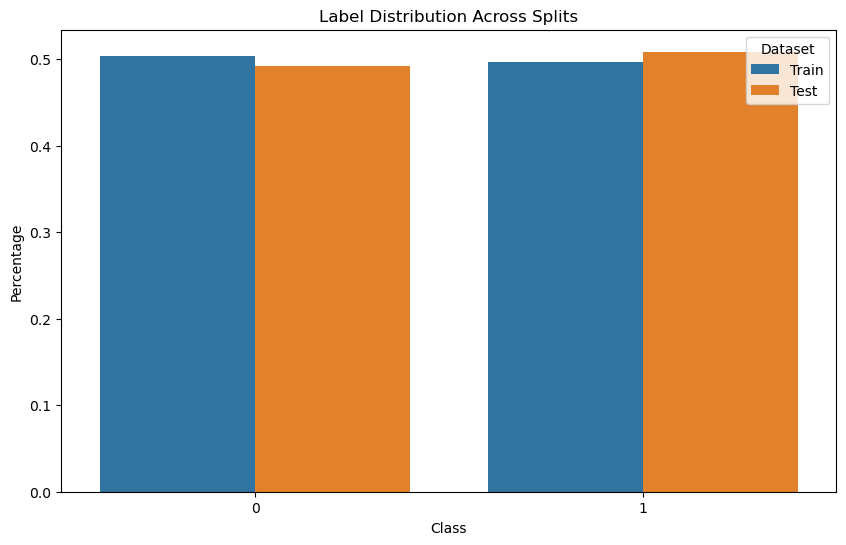

In [ ]:
# check the distribution of y in training, validation, and testing data
def get_dist_df(name, index_array):
    temp_df = df_cleaned.iloc[index_array]['label'].value_counts(normalize=True).reset_index()
    temp_df.columns = ['Class', 'Percentage']
    temp_df['Dataset'] = name
    return temp_df

plot_df = pd.concat([
    get_dist_df("Train", train_idx),
    get_dist_df("Test", test_idx)
])

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Class', y='Percentage', hue='Dataset')
plt.title("Label Distribution Across Splits")
plt.show()

The distribution of the target variable is balanced in the training and testing datasets.

## 5.1 Logistic regression model

### 5.1.1 Model training and hyperparameter tuning

I use GridSearchCV to conduct a grid search of different combination of hyperparameters, including `penalty`, `solver`, `l1_ratio`, and `C`, altogether 24 combinations. For models with every possible combination of hyperparameters, the one with the highest accuracy score on the validation data will be stored as the best performing model.

In [ ]:
lr = LogisticRegression(random_state=42)
parameters_lr = [
    {"penalty": ["l2"], "solver": ["lbfgs", "saga"], "C": [1e-3, 1e-1, 1, 10]},
    {"penalty": ["l1"], "solver": ["liblinear", "saga"], "C": [1e-3, 1e-1, 1, 10]},
    {"penalty": ["elasticnet"], "solver": ["saga"], "l1_ratio": [0.2, 0.8], "C": [1e-3, 1e-1, 1, 10]}
]       # 24 combinations

grid_cv_lr = GridSearchCV(estimator = lr, param_grid = parameters_lr, cv=5)

grid_cv_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'saga']}, {'C': [0.001, 0.1, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [ ]:
# get the hyperparameters for the best performing model
grid_cv_lr.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

In [ ]:
# get the highest mean_accuracy_score
grid_cv_lr.best_score_

0.8627751571707531

In [ ]:
# show parameter combinations with top 10 mean_accuracy_scores
import pandas as pd

results_lr = pd.DataFrame(grid_cv_lr.cv_results_)
results_lr = results_lr.sort_values("mean_test_score", ascending=False)

results_lr[[
    "param_penalty",
    "param_solver",
    "param_C",
    "param_l1_ratio",
    "mean_test_score",
    "rank_test_score"]].head(10)

,param_penalty,param_solver,param_C,param_l1_ratio,mean_test_score,rank_test_score
4,l2,lbfgs,1.0,NaN,0.862775,1
5,l2,saga,1.0,NaN,0.862598,2
20,elasticnet,saga,1.0,0.2,0.858160,3
7,l2,saga,10.0,NaN,0.855496,4
6,l2,lbfgs,10.0,NaN,0.855318,5
22,elasticnet,saga,10.0,0.2,0.851236,6
2,l2,lbfgs,0.1,NaN,0.849640,7
3,l2,saga,0.1,NaN,0.849462,8
21,elasticnet,saga,1.0,0.8,0.843071,9
13,l1,saga,1.0,NaN,0.840408,10


The best-performing hyperparameter combination was L2 penalty with the lbfgs solver and C = 1.0, achieving a validation accuracy of 0.8628.

From the search results, we can observe that moderate regularization strength (C = 1.0) tends to yield higher accuracy than stronger regularization (e.g., C = 10.0) and weaker regularization (C = 0.1), suggesting that overly strong or weak regularization does not further improve generalization performance.

In addition, L2 regularization consistently outperforms Elastic Net (with l1_ratio = 0.2) and L1 penalty, indicating that purely ridge-type regularization is more suitable for this dataset than other penalties.


In [ ]:
# define and fit the best performing logistic regression model
best_model_lr = LogisticRegression(penalty='l2', solver='lbfgs', C=1, random_state=42)
best_model_lr.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` pro

### 5.1.2 Model evaluation

Classification Report:

In [ ]:
# calculate the predicted y
y_pred_test_lr = best_model_lr.predict(X_test)
y_pred_test_lr

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [ ]:
# calculate the probability of y
y_predprob_test_lr = best_model_lr.predict_proba(X_test)
np.round(y_predprob_test_lr, 3)

array([[0.783, 0.217],
       [0.915, 0.085],
       [0.523, 0.477],
       ...,
       [0.055, 0.945],
       [0.785, 0.215],
       [0.799, 0.201]])

In [ ]:
# print confusion matrix
print(confusion_matrix(y_test, y_pred_test_lr))

[[1052  135]
 [ 188 1040]]


In [ ]:
# print classification report
print(classification_report(y_test, y_pred_test_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1187
           1       0.89      0.85      0.87      1228

    accuracy                           0.87      2415
   macro avg       0.87      0.87      0.87      2415
weighted avg       0.87      0.87      0.87      2415



ROC-AUC:

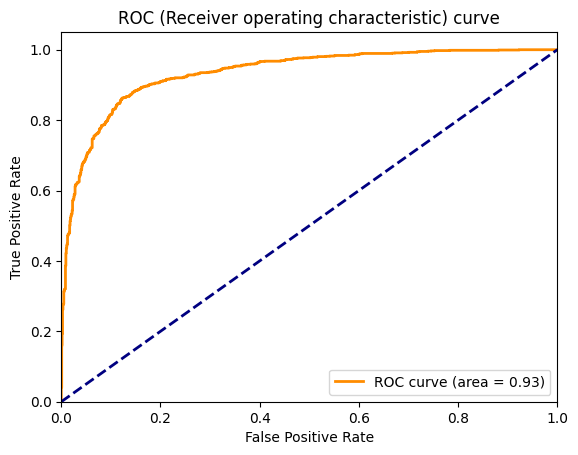

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true = y_test, y_score = y_predprob_test_lr[:,1], pos_label=1)
roc_auc = auc(fpr, tpr) # area under ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC (Receiver operating characteristic) curve')
plt.legend(loc="lower right")
plt.show()

The classification report shows balanced performance across both classes, with precision and recall ranging from 0.85 to 0.89 and an overall f1-score of 0.87, indicating that the model achieves strong classification performance.

The ROC curve yields an AUC of 0.93, which reflects good discriminative ability and suggests that the model can effectively separate positive and negative instances across different decision thresholds.

Overall, the model demonstrates robust predictive performance on all the evaluation metrics, indicating good generalization on the testing dataset.

Qualitative evaluation:

In [ ]:
feature_to_coef_lr = {word: float("%.3f" % coef) for word, coef in zip(vectorizer_tfidf.get_feature_names_out(), best_model_lr.coef_[0])}
# Top features that are predictive of positive sentiment
print("Top positive features:")
sorted(feature_to_coef_lr.items(), key=lambda x: x[1], reverse=True)[:10]

Top positive features:


[('great', 6.227),
 ('love', 6.013),
 ('amazing', 4.28),
 ('perfect', 3.848),
 ('best', 3.489),
 ('nice', 3.07),
 ('good', 2.949),
 ('easy', 2.831),
 ('well', 2.637),
 ('excelente', 2.561)]

In [ ]:
# Top features that are predictive of positive sentiment
print("Top negative features:")
sorted(feature_to_coef_lr.items(), key=lambda x: x[1], reverse=False)[:10]
# Most of top-10 negative words are reliable evidence of indicating negative sentiments

Top negative features:


[('not', -7.825),
 ('disappointed', -3.015),
 ('horrible', -2.732),
 ('broke', -2.53),
 ('money', -2.42),
 ('no', -2.373),
 ('waste', -2.265),
 ('cheap', -2.062),
 ('poor', -1.963),
 ('terrible', -1.951)]

Feature coefficients:

In [ ]:
# show feature importance
coef_lr = best_model_lr.coef_[0]
feature_names_lr = vectorizer_tfidf.get_feature_names_out()

df_coef_lr = pd.DataFrame({
    'features': feature_names_lr,
    'coefficients': coef_lr
})

df_coef_lr['coefficients'] = df_coef_lr['coefficients'].round(2)
df_coef_lr = df_coef_lr.sort_values(by='coefficients', ascending=False)

df_coef_lr.head(10)

,features,coefficients
1566,great,6.23
2083,love,6.01
111,amazing,4.28
2554,perfect,3.85
309,best,3.49
2348,nice,3.07
1544,good,2.95
1111,easy,2.83
4003,well,2.64
1214,excelente,2.56


The top positive predictors (e.g., *great*, *love*, *great*, *amazing*, *perfect*, *best*) are strongly evaluative adjectives and verbs that directly express satisfaction, so their large positive coefficients are intuitive and consistent with positive sentiment.

The strongest negative predictors (e.g., *not*, *horrible*, *terrible*, *disappointed*, *broke*) also clearly signal dissatisfaction or product failure, and the very large negative weight for *not* is reasonable given its role as a negation marker.

Overall, the coefficients are linguistically coherent and align well with sentiment cues, suggesting that the model is capturing meaningful lexical signals.

### 5.1.3 Show Errors for Further Analysis

In this section, I extract and show the mispredicted samples. The purpose is to detect common errors made by the supervised models and analyze the common errors in the "5.3 Error Analysis" section.

In [ ]:
# extract errors
df_test_lr = df_cleaned.iloc[test_idx]
df_test_lr['pred_label'] = y_pred_test_lr

pd.set_option('display.max_colwidth', None)
df_test_lr[df_test_lr['label'] != df_test_lr['pred_label']].head()[['review','label','pred_label']]

,review,label,pred_label
5608,Silky smooth but slips off The material is great. Its more like a doo rag or wave cap. It just keeps slipping off while im sleep,0,1
3458,"Works well for my hair dryer I got this to help me attach my Black Orchid Diffuser to my Babyliss Portofino Dryer. It works great, but it will eventually fall off if I have to dry for a long time - it gets loose with the heat. It doesn’t fall off every time, but I make sure it is secure before drying. It takes forever to dry my hair, so I need to check it occasionally to make sure it is still secure. The diffuser does not stay put at all without this attachment, so definitely need it!<br /><br />UPDATE: I received a message from Val, the inventor of SnozzlePro - she gave me a tip that helped a lot. I had the nozzle upside down. When I turned it around the way she said to put it, it fit better and did not come off! Changed to 5 stars! Thanks Val!",1,0
4174,Ok product but still leaves my daughter hair oily It leaves my daugters hair oily the products are more for like smaller children I think.,0,1
6692,Easy to use This was super simple to wrap my hair around. The satin is soft and scrunchies are too. It’s not uncomfortable to sleep in either. This is a gray way to save your hair from heat and get beautiful curls! Just be sure to dampen your hair before wrapping it!,1,0
4362,"Great for tinder headed girls… Mom of 3 girls, 2/3 are tinder headed and have THICK hair. These are the only brushes we use, I think we have like 10…",0,1


The above errors show that the logistic regression classifier do not perform well on reviews with mixed sentiments, such as 5608, 3458, and 4174. These reviews expressed compliments on certain aspects of the product but pointed out other problems, making it difficult for the classifier to predict the label based on the tf-idf matrix.

## 5.2 Tree-based models

### 5.2.1 Decision tree classifier

#### Model training and hyperparameter tuning

Similarly, for the decision tree classifier, I also use GridSearchCV for hyperparameter tuning to identify the best performing model. I explored `criterion`, `max_depth`, `min_samples_split`, and `min_samples_leaf`, altogether 216 combinations.

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
param_dt = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 8, 12, 16, 18, 20],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 2, 3]
}    # 216 combinations

grid_cv_dt = GridSearchCV(estimator = dt, param_grid = param_dt, cv=5)

grid_cv_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 8, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [ ]:
# get the hyperparameters for the best performing model
grid_cv_dt.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [ ]:
# get the highest mean accuracy score
grid_cv_dt.best_score_

0.7732990176532425

In [ ]:
# show parameter combinations with top 10 mean_accuracy_scores
import pandas as pd

results_dt = pd.DataFrame(grid_cv_dt.cv_results_)
results_dt = results_dt.sort_values("mean_test_score", ascending=False)

results_dt[[
    "param_criterion",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_test_score",
    "rank_test_score"]].head(10)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
0,gini,None,2,1,0.773299,1
8,gini,None,2,3,0.772058,2
9,gini,None,4,3,0.772058,2
10,gini,None,6,3,0.772058,2
3,gini,None,8,1,0.771879,5
11,gini,None,8,3,0.770817,6
146,log_loss,None,6,1,0.770107,7
74,entropy,None,6,1,0.770107,7
2,gini,None,6,1,0.770103,9
152,log_loss,None,2,3,0.769755,10


The best-performing hyperparameter combination was criterion = gini, max_depth = None, min_samples_split = 2, and min_samples_leaf = 1, achieving a validation accuracy of 0.7733.

From the grid search results, we observe that the gini criterion consistently outperforms entropy and log_loss, suggesting that impurity reduction measured by Gini index is better aligned with this dataset.

In addition, larger tree depths (no limitation) always yield higher accuracy than shallower trees, indicating that the model benefits from higher complexity, although this may also increase the risk of overfitting compared to logistic regression.

In [ ]:
# define and fit the best performing model
best_model_dt = DecisionTreeClassifier(random_state=42, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1)
best_model_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### Model Evaluation

In [ ]:
# apply the fitted model to prediction the label for the test data
y_pred_test_tree = best_model_dt.predict(X_test)

Classification Report:

In [ ]:
# print confusion matrix
print(confusion_matrix(y_test, y_pred_test_tree))

[[954 233]
 [308 920]]


In [ ]:
# print classification report
print(classification_report(y_test, y_pred_test_tree))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1187
           1       0.80      0.75      0.77      1228

    accuracy                           0.78      2415
   macro avg       0.78      0.78      0.78      2415
weighted avg       0.78      0.78      0.78      2415



ROC-AUC:

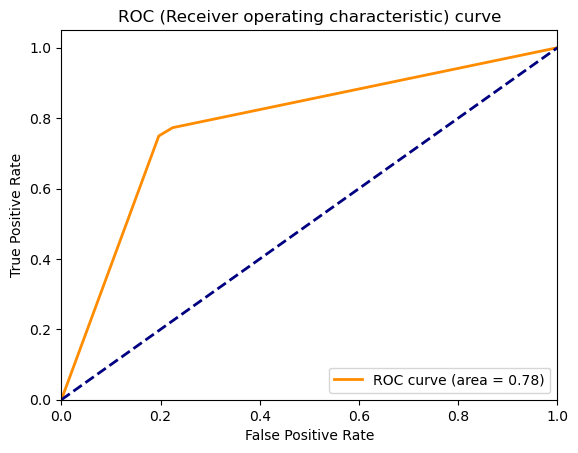

In [ ]:
# calculate predicted probabilities of each test data
y_predprob_test_tree = best_model_dt.predict_proba(X_test)

# show ROC curve
fpr, tpr, thresholds = roc_curve(y_true = y_test, y_score = y_predprob_test_tree[:,1], pos_label=1)
roc_auc = auc(fpr, tpr) # area under ROC curve

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC (Receiver operating characteristic) curve')
plt.legend(loc="lower right")
plt.show()

The classification report shows an overall f1-score of 0.78, with higher recall for class 0 (0.80) but relatively lower recall for class 1 (0.75), indicating that the model tends to miss a considerable number of positive instances.

The ROC curve yields an AUC of 0.78, which reflects moderate discriminative ability but is clearly weaker than that of the logistic regression model.

Overall, the decision tree demonstrates acceptable but unbalanced performance, with a bias toward predicting the negative class and noticeably lower generalization capacity compared to the linear model.

#### Visualization and feature importance

In [ ]:
import graphviz
from sklearn.tree import export_graphviz

In [ ]:
# visualize the best-performing decision tree
dot_tree_top3 = export_graphviz(best_model_dt,
                out_file=None,
                feature_names=vectorizer_tfidf.get_feature_names_out(),
                class_names=['0', '1', '2'],
                filled=True,
                rounded=True,
                special_characters=True,
                max_depth=3)
graph_top2 = graphviz.Source(dot_tree_top3)
graph_top2.render(
    filename="decision_tree_top3_viz",
    format="png",
    cleanup=True)

'decision_tree_top3_viz.png'

In [ ]:
# show feature importance
importances_dt = best_model_dt.feature_importances_
feature_names_dt = vectorizer_tfidf.get_feature_names_out()

df_importance_dt = pd.DataFrame({
    'features': feature_names_dt,
    'importances': importances_dt
})

df_importance_dt['importances'] = df_importance_dt['importances'].round(2)
df_importance_dt = df_importance_dt.sort_values(by='importances', ascending=False)

df_importance_dt.head(10)

,features,importances
2369,not,0.16
1566,great,0.06
2083,love,0.06
1544,good,0.02
2554,perfect,0.02
309,best,0.02
111,amazing,0.02
1297,favorite,0.01
1111,easy,0.01
4003,well,0.01


The decision tree primarily splits on “not”, which has the highest feature importance (0.16), indicating that negation is the most influential signal in separating positive and negative sentiment.

At the top levels of the tree, the model further splits on strongly evaluative words such as “great” and “love”, showing that highly polarized sentiment adjectives are splitted on early.

Overall, this splitting strategy is intuitive: negation and strongly positive adjectives are linguistically important sentiment markers, so it is reasonable that the tree prioritizes these features.

#### Show Errors for Further Analysis

In [ ]:
# show error samples
df_test_dt = df_cleaned.iloc[test_idx]
df_test_dt['pred_label'] = y_pred_test_tree
df_test_dt[df_test_dt['label'] != df_test_dt['pred_label']].head()[['review','label','pred_label']]

,review,label,pred_label
4707,A good product I’ve been using this product fo...,1,0
5608,Silky smooth but slips off The material is gre...,0,1
5965,"Fake El producto viene amarillo, parece falso",0,1
3458,Works well for my hair dryer I got this to hel...,1,0
4739,Primer I didn't like the fact that my pores st...,0,1


Similar with the linear regression classifier, the decision tree classifier also have difficulty predicting the correct label for reviews with mixed comments.

### 5.2.2 Random forest classifier

#### Model training and hyperparameter tuning

For random forest classifier, I also use GridSearchCV to perform hyperparametor tuning. I explored `criterion`, `n_estimators`, `max_features`, `max_depth`, and `min_samples_leaf`, altogether 144 combinations.

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_rf = {
    "criterion": ["gini", "entropy", "log_loss"],
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 16, 20],
    "max_features": [None, "sqrt", "log2"],
    "min_samples_leaf": [1, 3]
}    # 144 combinations

grid_cv_rf = GridSearchCV(estimator = rf, param_grid = param_rf, cv=5)

grid_cv_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [ ]:
# get the hyperparameters of the best performing model
grid_cv_rf.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'n_estimators': 200}

In [ ]:
# get the highest accuracy score
grid_cv_rf.best_score_

0.8553151216467743

In [ ]:
# show parameter combinations with top 10 mean_accuracy_scores
results_rf = pd.DataFrame(grid_cv_rf.cv_results_)
results_rf = results_rf.sort_values("mean_test_score", ascending=False)

results_rf[[
    "param_criterion",
    "param_n_estimators",
    "param_max_depth",
    "param_max_features",
    "param_min_samples_leaf",
    "mean_test_score",
    "rank_test_score"]].head(10)

,param_criterion,param_n_estimators,param_max_depth,param_max_features,param_min_samples_leaf,mean_test_score,rank_test_score
9,gini,200,None,log2,1,0.855315,1
57,entropy,200,None,log2,1,0.854961,2
105,log_loss,200,None,log2,1,0.854961,2
8,gini,100,None,log2,1,0.853720,4
56,entropy,100,None,log2,1,0.853719,5
104,log_loss,100,None,log2,1,0.853719,5
58,entropy,100,None,log2,3,0.848393,7
106,log_loss,100,None,log2,3,0.848393,7
59,entropy,200,None,log2,3,0.847505,9
107,log_loss,200,None,log2,3,0.847505,9


The best-performing configuration was criterion = gini, n_estimators = 200, max_features = log2, max_depth = None, and min_samples_leaf = 1, achieving a validation accuracy of 0.855.

From the results, we can observe that when min_samples_leaf = 1, max_depth = None, and max_features = log2, gini outperforms entropy and log_loss, suggesting that gini is better suited to this dataset than the other two criteria.

In addition, using max_features = log2 always yields the strongest performance, indicating that restricting the number of features considered at each split improves generalization.

In [ ]:
# define and fit the best performing model
best_model_rf = RandomForestClassifier(random_state=42, criterion="gini", n_estimators=200, max_depth=None, max_features="log2", min_samples_leaf=1)
best_model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Model evaluation

In [ ]:
# apply the fitted model to prediction the label for the test data
y_pred_test_rf = best_model_rf.predict(X_test)

Classification report:

In [ ]:
# print the confusion matrix
print(confusion_matrix(y_test, y_pred_test_rf))

[[1057  130]
 [ 210 1018]]


In [ ]:
# print classification report
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1187
           1       0.89      0.83      0.86      1228

    accuracy                           0.86      2415
   macro avg       0.86      0.86      0.86      2415
weighted avg       0.86      0.86      0.86      2415



ROC-AUC:

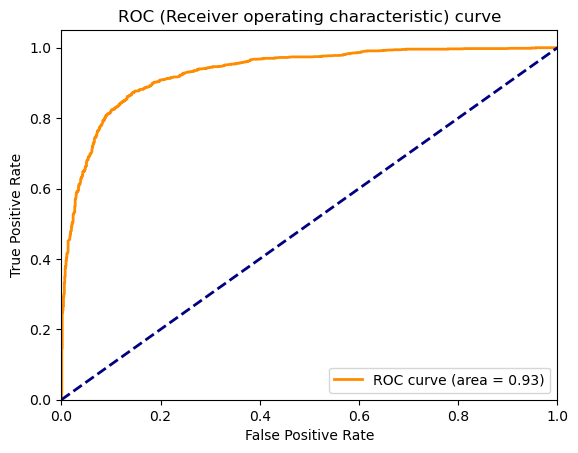

In [ ]:
# calculate predicted probabilities of each test data
y_predprob_test_rf = best_model_rf.predict_proba(X_test)

# show ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_true = y_test, y_score = y_predprob_test_rf[:,1], pos_label=1)
roc_auc_rf = auc(fpr_rf, tpr_rf) # area under ROC curve

plt.figure()
lw = 2
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC (Receiver operating characteristic) curve')
plt.legend(loc="lower right")
plt.show()

The classification report shows strong and well-balanced performance, with precision and recall between 0.83 and 0.89 for both classes and an overall f1-score of 0.86, indicating stable performance without substantial class bias.

The ROC curve yields an AUC of 0.93, demonstrating excellent discriminative ability and strong separation between positive and negative instances across thresholds.

Overall, the random forest achieves high predictive performance comparable to logistic regression, significantly outperforming a single decision tree classifier.

Feature importance:

In [ ]:
# show feature importance
importances_rf = best_model_rf.feature_importances_
feature_names_rf = vectorizer_tfidf.get_feature_names_out()

df_importance_rf = pd.DataFrame({
    'features': feature_names_rf,
    'importances': importances_rf
})

df_importance_rf['importances'] = df_importance_rf['importances'].round(2)
df_importance_rf = df_importance_rf.sort_values(by='importances', ascending=False)

df_importance_rf.head(10)

,features,importances
2369,not,0.05
1566,great,0.03
2083,love,0.02
1544,good,0.01
2554,perfect,0.01
111,amazing,0.01
4003,well,0.01
1111,easy,0.01
309,best,0.01
2357,no,0.01


The random forest assigns the highest importance to “not”, followed by strongly evaluative words such as “love” and “great”, indicating that negation and explicit sentiment terms remain the most influential predictors.

In addition, words like “no” capture dissatisfaction or product failure, while “perfect”, “amazing”, and “best” signal positive evaluation, which aligns well with sentiment.

Overall, the feature importance distribution is intuitive and linguistically coherent, suggesting that the ensemble model is relying on meaningful sentiment-bearing tokens.

#### Show Errors for Further Analysis

In [ ]:
# show error samples
df_test_rf = df_cleaned.iloc[test_idx]
df_test_rf['pred_label'] = y_pred_test_rf
df_test_rf[df_test_rf['label'] != df_test_rf['pred_label']].head()[['review','label','pred_label']]

,review,label,pred_label
7891,Not as easy as shown My long haired yellow lab...,0,1
5608,Silky smooth but slips off The material is gre...,0,1
3458,Works well for my hair dryer I got this to hel...,1,0
4174,Ok product but still leaves my daughter hair o...,0,1
4362,"Great for tinder headed girls… Mom of 3 girls,...",0,1


Based on the above error reviews, we can observe that dicision tree classifier also make mistakes on reviews with both positive and negative comments.

## 5.3 Error Analysis

In this section, I will analyze some common errors made by the three classifiers. I first use the "interpretation" function to annotate the word coefficients from the logistic regression for the reviews, and then interpret the reason behind the errors.

In [ ]:
# show the error reviews and word coefficients
import textwrap

RED = '\033[1;31;48m'
BLUE = '\033[1;34;48m'
END = '\033[1;37;0m'

def interpretation(text, vectorizer, wrap_length=250, use_color=True):
    """
    Annotate each word feature with the learned coefficient, and color based on
    coefficient direction
    """
    # Make the annotated string
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            to_append = wd

            # Red is more negative, blue is more positive
            if use_color and best_model_lr.coef_[0][wd_id] < 0:
                to_append = RED + to_append + END
            elif use_color and best_model_lr.coef_[0][wd_id] > 0:
                to_append = BLUE + to_append + END

            to_append = to_append+'('+("%.3f" % best_model_lr.coef_[0][wd_id])+')'


            analysis.append(to_append)
        else:
            analysis.append(wd)
    result = ' '.join(analysis)

    # Wrap the string for easier viewing
    wrapper = textwrap.TextWrapper(width=wrap_length)
    result = wrapper.fill(text=result)

    print(result)

In [ ]:
# annotated review 5608
interpretation(df_cleaned.loc[5608]['cleaned_review'],vectorizer_tfidf)

Silky smooth(1.143) but slips(-0.140) off The material(-0.328) is great(6.227) Its more like(0.073) a doo rag(0.173) or
wave(0.101) cap(-0.429) It just keeps(1.468) slipping(-0.148) off while im(0.265) sleep(-0.124)


In [ ]:
# original review 5608
df_cleaned.loc[5608]['review']

'Silky smooth but slips off The material is great. Its more like a doo rag or wave cap. It just keeps slipping off while im sleep'

In [ ]:
# annotated review 3458
interpretation(df_cleaned.loc[3458]['cleaned_review'],vectorizer_tfidf)

Works well(2.637) for my hair(-0.435) dryer(-0.158) I got this to help(0.580) me attach(0.050) my Black Orchid Diffuser to my Babyliss Portofino Dryer It
works great(6.227) but it will eventually(-0.394) fall(-0.768) off if I have to dry(0.025) for a long(0.444) time(0.938) it
gets(-0.714) loose(-0.062) with the heat(0.158) It doesn t fall(-0.768) off every(0.004) time(0.938) but I
make(-0.111) sure(-0.176) it is secure(0.307) before drying(-0.426) It takes(0.578) forever(-0.223) to dry(0.025) my
hair(-0.435) so I need(0.904) to check(-0.447) it occasionally(0.080) to make(-0.111) sure(-0.176) it is still(0.005)
secure(0.307) The diffuser(-0.220) does not(-7.825) stay(-0.931) put(-0.023) at all without(0.790) this
attachment(-0.078) so definitely(1.005) need(0.904) it UPDATE I received(-1.080) a message(-0.124) from Val the inventor of SnozzlePro she
gave(-0.462) me a tip(0.165) that helped(1.028) a lot(-0.145) I had the nozzle(-0.286) upside(0.003) down When I
turned(-0.921) it around

In [ ]:
# annotated review 3458
df_cleaned.loc[3458]['review']

'Works well for my hair dryer I got this to help me attach my Black Orchid Diffuser to my Babyliss Portofino Dryer. It works great, but it will eventually fall off if I have to dry for a long time - it gets loose with the heat.  It doesn’t fall off every time, but I make sure it is secure before drying. It takes forever to dry my hair, so I need to check it occasionally to make sure it is still secure. The diffuser does not stay put at all without this attachment, so definitely need it!<br /><br />UPDATE:  I received a message from Val, the inventor of SnozzlePro - she gave me a tip that helped a lot. I had the nozzle upside down. When I turned it around the way she said to put it, it fit better and did not come off!  Changed to 5 stars!  Thanks Val!'

The above two reviews are mispredicted by all the three classifiers. The first review is a false positive error where the logistic regression classifier assigns more weights to positive descriptors that do not reflect the product's actual utility. Specifically, the word "great" has a coefficient of 6.227 in the logistic regression model, and it is also a feature with top 2 importance in the tree-based models. While the reviewer clearly states a  problem that the item "slips off", the negative coefficients associated with "slips" (-0.140) and "slipping" (-0.148) are far too small. Therefore, the classifiers incorrectly predict that the review corresponds to a high rating.

The second review is a false negative exmaple. The original review shows that the customer updated the review once and changed the rating to 5 stars, while the initial negative comments were still attached. This review used "not" for several times, a word with a negative coefficient of -7.825 and top 1 feature importance in the tree-based models. Although sometimes the customer used "not" to express positive comments such as "did not come off", the cumulative negative score and feature importance easily make the review be predicted as low rating.

To sum up, these errors highlight a common weakness in supervised models that rely on individual words without accounting for the context within a single text.

## 5.4 Interpretation

Across the three classifiers, logistic regression and random forest clearly outperform the single decision tree in terms of both accuracy and discriminative ability. Logistic regression achieves an f-1 score of 0.87 and an AUC of 0.93, with well-balanced precision and recall across classes, indicating strong linear separability in the high-dimensional lexical feature space. The random forest reaches a slightly lower f-1 score (0.86) and the same AUC (0.93), suggesting that ensemble-based nonlinear modeling can maintain excellent generalization. In contrast, the single decision tree yields lower accuracy (0.78) and AUC (0.78), with noticeably weaker recall for the positive class, reflecting higher variance and limited generalization when relying on a single partition.

From a modeling perspective, these differences are consistent with the properties of each algorithm. Logistic regression adopted L2 regularization, which is well-suited for sparse text data and reduces overfitting. The decision tree, although interpretable and capable of modeling nonlinear splits (e.g., on “not” or “great”), is prone to instability and overfitting, especially at greater depths. The random forest mitigates this weakness by aggregating many trees, improving robustness and reducing variance. Overall, the results suggest that ensemble methods and regularized linear models are both highly effective for sentiment classification, while a single tree is comparatively less reliable.

Referring to RQ1: Can customer review text be used to predict whether a review corresponds to a high or low product rating?
- Customer reviews can predict the high or low rating of a product with logistic regression classifier, decision tree classifier, and random forest classifier. The logistic regression classifier has the strongest prediction ability.

Based on the model evaluation of the three classifiers, I choose the optimal Logistic Regression Classifier because it has the highest overall accuracy, f-1 score and more balanced recall for both classes.

In [ ]:
# store the predicted y probability in the data frame for future computing
y_predprob_all_lr = best_model_lr.predict_proba(X)
high_rating_prob = y_predprob_all_lr[:, 1]
df_cleaned["high_rating_prob"] = high_rating_prob
df_cleaned.head()

,rating,title,text,parent_asin,timestamp,verified_purchase,product_title,cat_rating,label,review,length,cleaned_review,high_rating_prob
0,4,Amber,Smells good one full dab is all you need,B07S1F8892,2023-03-24 20:03:30.736,True,Hijaz Amber Oil Arabian Fragrance Alcohol Free...,high,1,Amber Smells good one full dab is all you need,46,Amber Smells good one full dab is all you need,0.659131
1,5,Awesome!,This eye liner stays on....about time!,B00IWIKX72,2023-03-25 05:13:41.002,True,Liquidlast Liner # Point Black,high,1,Awesome! This eye liner stays on....about time!,47,Awesome This eye liner stays on about time,0.777769
2,1,Damaged items,Product came defective. The slip solution leak...,B09NLMYH7T,2023-02-05 21:41:43.334,True,Builder Gel Nail Kit -2 oz Clear&Pink Nail Ext...,low,0,Damaged items Product came defective. The slip...,101,Damaged items Product came defective The slip...,0.057786
3,3,I wanted to love this!,This is nothing like the pictures. I needed a ...,B0B6DQV5N9,2023-02-10 19:17:43.352,True,Freckle Makeup Pen Freckle Air Cushion Rainbow...,low,0,I wanted to love this! This is nothing like th...,163,I wanted to love this This is nothing like th...,0.311398
4,2,Colors not accurate,"I like these bottles, but I got three pink and...",B07RLQ4LV5,2023-03-11 17:19:27.671,True,4PCS 90ml Portable Travel Bottle Set Mermaid S...,low,0,"Colors not accurate I like these bottles, but ...",99,Colors not accurate I like these bottles but ...,0.077238


In [ ]:
df_cleaned.to_csv("/content/drive/MyDrive/30100_Individual/Product_Review_beauty2023_predict.csv",index=False)

# 6. Unsupervised model: BERTopic

Some outputs and visualizations in this section can only be visible on Google Clab.

I use BERTopic for topic modeling because the dataset consists of short, informal product reviews. Traditional models such as LDA often perform poorly on short texts because they rely on word frequency patterns. BERTopic leverages contextual sentence embeddings and clustering to capture semantic similarity between reviews, allowing it to identify coherent product aspects.

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.8 MB/s eta 0:00:00


In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 40.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a913b0632e010f8f8e2c5c5293500809ffc82e621f9f7c902f6769c8736537c0
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

## 6.1 Data Preparation and Cleaning

In the text data preprocessing for supervised learning, I have already cleaned the text data in terms of expanding contractions into normal words, removing html tags, non-alphabatic characters, url, punctuations, and shortening prolonged words. Here, I further clean the data for topic modeling.

In [ ]:
# read the dataset
df_topic = pd.read_csv("/content/drive/MyDrive/30100_Individual/Product_Review_beauty2023_predict.csv")

In [ ]:
def clean_for_topic_modeling(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    # 1) clean unmeaningful charaters
    text = re.sub(r'videoid\b[\w\s-]*', ' ', text, flags=re.IGNORECASE)

    # 2) clean html tags
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'&amp;', ' and ', text)
    text = re.sub(r'&quot;', ' ', text)
    text = re.sub(r'&#\d+;', ' ', text)

    # 3) clean URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 4) clean repetitive chracters
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)

    # 5) clean independent numbers or characters
    text = re.sub(r'\b[a-z]{1,2}\d+\b', ' ', text)
    text = re.sub(r'\b\d+[a-z]{1,2}\b', ' ', text)

    # 6) clean numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # 7) clean punctuations
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 8) clean spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_topic["topic_text"] = df_topic["cleaned_review"].astype(str).apply(clean_for_topic_modeling)

In [ ]:
# drop reviews that are too short
df_topic = df_topic[df_topic["topic_text"].notna()].copy()

df_topic["word_count"] = df_topic["topic_text"].str.split().str.len()
df_topic = df_topic[df_topic["word_count"] >= 5].copy()

In [ ]:
# drop non-english reviews
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

df_topic["is_english"] = df_topic["topic_text"].apply(is_english)
df_topic = df_topic[df_topic["is_english"]].copy()

In [ ]:
# drop reviews irrelevant with beauty
irrelevant = r'\b(squirrel|squirrels|rodent|rodents|mice|mosquito|mosquitoes|repellent)\b'
df_topic = df_topic[~df_topic["topic_text"].str.contains(irrelevant, regex=True, na=False)].copy()

In [ ]:
# build the list of docs
docs = df_topic["topic_text"].tolist()

In [ ]:
len(docs)

7049

In [ ]:
docs[:2]

['amber smells good one full dab is all you need',
 'awesome this eye liner stays on about time']

Define Stopwords and Vectorizer:

In [ ]:
stopwords = list(set([

    # platform / transaction noise
    'product','item','amazon','buy','bought','purchase','purchased',
    'order','ordered','arrived','shipping','delivery',
    'seller','delivered','packaged','quickly','fast',

    # generic verbs
    'use','used','using','work','works','working','try','tried','got',
    'thought','think','thinking','make','made','get','go','went','take','took',

    # review/meta noise
    'review','reviewing','thing','stuff','br',
    'recommend','recommended',

    # generic opinion words
    'good','great','nice','love','like','bad','best','better','worst',
    'perfect','loved','easy','amazing','excellent','awesome','wonderful',

    # vague high-frequency words
    'not','no','one','would','well','little','nothing',
    'ok','okay','everything','meh','wanted','expected',
    'worth','worked','described','even','time',

    # gift-related noise
    'gift','birthday','christmas',

    # pronouns
    'i','me','my','myself','we','our','ours','ourselves','you',"you're","you've","you'll","you'd",
    'your','yours','yourself','yourselves','he','him','his','himself','she',"she's",
    'her','hers','herself','it',"it's",'its','itself','they','them','their','theirs','themselves',

    # wh words
    'what','which','who','whom','this','that',"that'll",'these','those',
    'here','there','when','where','why','how',

    # auxiliary verbs
    'am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing',

    # articles
    'a','an','the',

    # conjunctions
    'and','but','if','or','because','as','until','while',

    # prepositions
    'of','at','by','for','with','about','against','between','into','through','during',
    'before','after','above','below','to','from','up','down','in','out','on','off','over','under',

    # discourse / quantity / intensifiers
    'again','further','then','once','now','still',
    'all','any','both','each','few','more','most','other','some','such','only','own','same',
    'so','than','too','very','really','quite','pretty','much',

    # contraction fragments
    's','t','d','ll','m','o','re','ve','y',

    # modals / negation fragments
    'can','will','just','should',"should've",
    'don',"don't",'ain','aren',"aren't",'couldn',"couldn't",'didn',"didn't",
    'doesn',"doesn't",'hadn',"hadn't",'hasn',"hasn't",'haven',"haven't",
    'isn',"isn't",'ma','mightn',"mightn't",'mustn',"mustn't",'needn',"needn't",
    'shan',"shan't",'shouldn',"shouldn't",'wasn',"wasn't",'weren',"weren't",
    'won',"won't",'wouldn',"wouldn't",

    # metadata fragments
    'videoid','ea','aa','bb','cc','dd','ee','fd','fe','fc','dc','cb','ffa',
    'ae','ba','bd','ed',

    # spanish noise
    'el','de','es','la','que','lo','para','muy',
    'una','un','con','por','del','las','los',
    'como','pero','se','en','ya',
    'producto','excelente','calidad','bueno','bien','buen','buena','olor','mucho'
]))

In [ ]:
# define vectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords)

## 6.2 Run Baseline BERTopic

In [ ]:
baseline_model = BERTopic(vectorizer_model=vectorizer_model,
    language='english', calculate_probabilities=True,
    verbose=True)

base_topics, base_probs = baseline_model.fit_transform(docs)

2026-03-08 06:08:44,610 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/221 [00:00<?, ?it/s]

2026-03-08 06:09:26,564 - BERTopic - Embedding - Completed ✓
2026-03-08 06:09:26,565 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 06:09:32,995 - BERTopic - Dimensionality - Completed ✓
2026-03-08 06:09:32,996 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 06:09:37,114 - BERTopic - Cluster - Completed ✓
2026-03-08 06:09:37,119 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 06:09:37,745 - BERTopic - Representation - Completed ✓


In [ ]:
base_topics[:10], base_probs[:10]

([0, 23, -1, -1, -1, -1, 4, -1, 13, 51],
 array([[0.09262232, 0.00358481, 0.00477919, ..., 0.00609846, 0.00582938,
         0.00379016],
        [0.00118764, 0.00178329, 0.00191534, ..., 0.00183295, 0.0033545 ,
         0.00137719],
        [0.00642007, 0.00473591, 0.00739254, ..., 0.00899158, 0.00688514,
         0.00435293],
        ...,
        [0.00476365, 0.00634671, 0.01238716, ..., 0.02218979, 0.00885336,
         0.00424949],
        [0.00663854, 0.00105555, 0.00123874, ..., 0.00161224, 0.00165496,
         0.00104186],
        [0.00246241, 0.00247112, 0.00580967, ..., 0.00576925, 0.00433502,
         0.00269001]]))

In [ ]:
baseline_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2488,-1_hair_skin_smell_color,"[hair, skin, smell, color, quality, money, pro...",[works great dries fast less is more use less ...
1,0,471,0_smell_scent_smells_perfume,"[smell, scent, smells, perfume, fragrance, sce...",[did not like this product this product did no...
2,1,326,1_nails_nail_polish_gel,"[nails, nail, polish, gel, coat, nail polish, ...",[excellent polish but very poor shipping with ...
3,2,140,2_cute_party_ears_comfortable,"[cute, party, ears, comfortable, bows, kids, q...",[great value you get so much for what you pay ...
4,3,137,3_wig_hat_lace_wigs,"[wig, hat, lace, wigs, looks, wig wig, wig loo...",[clown wig the wig looks like the picture if a...
...,...,...,...,...,...
106,105,10,105_bottle_manufacturer_bottle defective_refun...,"[bottle, manufacturer, bottle defective, refun...",[i m not entirely sure still the instructions ...
107,106,10,106_stiff_hold_leather stiff_dreads,"[stiff, hold, leather stiff, dreads, hold with...",[se dreads super stiff and rough they are the ...
108,107,10,107_absolutely many_ease simple_cute feels_har...,"[absolutely many, ease simple, cute feels, har...","[good and simple exactly what i needed, great ..."
109,108,10,108_contour_contour stick_stick_blends,"[contour, contour stick, stick, blends, makeup...",[jordana sculpt n go creamy contour stick medi...


In [ ]:
baseline_model.visualize_topics()

The baseline model generates too many topics which overlap each other. In the next steps, I perform hyperparameter tuning to lower the number of topics to an appropriate size.

## 6.3 Hyperparameter Tuning

In [ ]:
from umap.umap_ import UMAP
from hdbscan import HDBSCAN

In [ ]:
# increase n_neighbors
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42)

# increase min_cluster_size
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric='euclidean',
    cluster_selection_epsilon=0.1,
    cluster_selection_method='eom',
    prediction_data=True,
    gen_min_span_tree=True
)

# define maximum number of topics
ft_model = BERTopic(
    vectorizer_model=vectorizer_model,
    language='english',
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=15,
    calculate_probabilities=True,
    verbose=True
)

In [ ]:
ft_topics, ft_probs = ft_model.fit_transform(docs)

2026-03-08 06:01:59,520 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/221 [00:00<?, ?it/s]

2026-03-08 06:02:43,841 - BERTopic - Embedding - Completed ✓
2026-03-08 06:02:43,842 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 06:03:21,575 - BERTopic - Dimensionality - Completed ✓
2026-03-08 06:03:21,576 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 06:03:22,586 - BERTopic - Cluster - Completed ✓
2026-03-08 06:03:22,587 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-08 06:03:23,175 - BERTopic - Representation - Completed ✓
2026-03-08 06:03:23,177 - BERTopic - Topic reduction - Reducing number of topics
2026-03-08 06:03:23,191 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 06:03:23,794 - BERTopic - Representation - Completed ✓
2026-03-08 06:03:23,798 - BERTopic - Topic reduction - Reduced number of topics from 38 to 15


In [ ]:
ft_topics[:10], ft_probs[:10]

([-1, 0, 4, -1, -1, 1, 6, -1, 3, -1],
 array([[0.08779384, 0.00965271, 0.03797827, 0.33327026, 0.02476958,
         0.00558428, 0.01740441, 0.02349088, 0.01504218, 0.00706679,
         0.00838522, 0.00861719, 0.00620003, 0.00560625],
        [0.51803916, 0.00947113, 0.05454479, 0.03099483, 0.01637309,
         0.00870138, 0.02044748, 0.03580453, 0.01360792, 0.00940059,
         0.00759352, 0.00757147, 0.00907238, 0.00540979],
        [0.08663682, 0.0186521 , 0.04675844, 0.05769048, 0.63529825,
         0.0089627 , 0.02468776, 0.03393844, 0.01663199, 0.0135946 ,
         0.00962415, 0.03408775, 0.00704709, 0.00638945],
        [0.06150213, 0.01322737, 0.02709041, 0.0192002 , 0.01508927,
         0.01356729, 0.0133892 , 0.04538713, 0.0054508 , 0.01269603,
         0.00311732, 0.01098768, 0.00319745, 0.0023903 ],
        [0.11936297, 0.01999043, 0.04842153, 0.0349841 , 0.02477139,
         0.01987105, 0.02260143, 0.21030115, 0.01034254, 0.01514326,
         0.00575029, 0.01562026, 0.00604

In [ ]:
ft_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1707,-1_smell_hair_smells_scent,"[smell, hair, smells, scent, color, soft, qual...",[love this very nice easy and simple to use co...
1,0,1164,0_skin_lashes_face_eyes,"[skin, lashes, face, eyes, cream, eye, dry, da...",[skin irritation i really wanted this product ...
2,1,1120,1_cute_quality_money_price,"[cute, quality, money, price, small, size, fit...","[waste your money not worth it for the price, ..."
3,2,851,2_hair_wig_shampoo_conditioner,"[hair, wig, shampoo, conditioner, curl, curler...",[third time is a charm i m these photos i m on...
4,3,538,3_smell_scent_smells_deodorant,"[smell, scent, smells, deodorant, soap, fragra...","[love the smell really good smells nice, smell..."
5,4,349,4_bottle_bottles_pump_broken,"[bottle, bottles, pump, broken, opened, open, ...",[needs instructions for first use but so far s...
6,5,332,5_nails_nail_polish_gel,"[nails, nail, polish, gel, coat, nail polish, ...",[they are for baby nails the nails are nice an...
7,6,277,6_hair_clips_blades_comb,"[hair, clips, blades, comb, shaver, razor, cli...",[very nice clips these clips are strong and ea...
8,7,235,7_color_colors_purple_blonde,"[color, colors, purple, blonde, palette, hair,...","[great color i love the color, color i did not..."
9,8,170,8_brush_brushes_bristles_dogs,"[brush, brushes, bristles, dogs, dog, hair, so...",[amazing brush i like everything about this br...


In [ ]:
ft_model.visualize_topics()

In [ ]:
ft_model.visualize_barchart(top_n_topics=15)

The fine-tuned model generates much better results than the baseline model. Overall, the 14 topic do not overlap with each other, and the top keywords of each topic makes sense.

## 6.4 Model Evaluation

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.2 MB/s eta 0:00:00


In [ ]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

In [ ]:
# get coherence score based on topic words
docs = df_topic["topic_text"].tolist()
tokenized_docs = [doc.split() for doc in docs]

dictionary = Dictionary(tokenized_docs)

topics = ft_model.get_topics()

topic_words = []
for topic_id in topics:
    if topic_id == -1:
        continue
    words = [word for word, _ in topics[topic_id]]
    topic_words.append(words)

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()

print("topic coherence (c_v):", coherence_score)

topic coherence (c_v): 0.47018509422195776


The model achieves a coherence score of 0.47, indicating that the top words within each topic tend to co-occur frequently in the corpus and that the topics are semantically interpretable.

Store the topic data into the dataframe:

In [ ]:
topic_label_map = {
    -1: "unassigned",

    0: "product_skin_eye_face",
    1: "dimension_size_quality_value",
    2: "product_hair_care_wigs",
    3: "dimension_fragrance_scent",
    4: "dimension_packaging_bottle_pump",
    5: "product_nail_products",
    6: "product_hair_tools_clips_shavers",
    7: "dimension_color_shade",
    8: "product_brushes_bristles",
    9: "product_glue_tape",
    10: "product_dental_tools",
    11: "dimension_durability",
    12: "product_waxing_hair_removal",
    13: "product_dryer_diffuser_fit"
}

df_topic["topic"] = ft_topics
df_topic["topic_prob"] = [
    float(np.max(p)) if isinstance(p, np.ndarray) else np.nan
    for p in ft_probs
]
df_topic["topic_name"] = df_topic["topic"].map(topic_label_map)

In [ ]:
df_topic[["cleaned_review", "rating", "high_rating_prob", "topic_name"]]

,cleaned_review,rating,high_rating_prob,topic_name
0,Amber Smells good one full dab is all you need,4,0.659131,unassigned
1,Awesome This eye liner stays on about time,5,0.777769,product_skin_eye_face
2,Damaged items Product came defective The slip...,1,0.057786,dimension_packaging_bottle_pump
3,I wanted to love this This is nothing like th...,3,0.311398,unassigned
4,Colors not accurate I like these bottles but ...,2,0.077238,unassigned
...,...,...,...,...
8039,Expired I purchased this item December just ...,1,0.213731,unassigned
8041,Game Changer Stamping Polish So Many Uses A ...,5,0.369036,product_nail_products
8042,Eye lashes Not worth wasting your money on,1,0.128938,product_skin_eye_face
8043,Scent Does Not Last These scents did not last ...,2,0.348610,dimension_fragrance_scent


## 6.5 Interpretation

I use BERTopic to calssify the reviews into 14 topics. Judging from the top keywords of each topic, some of the topics groups reviews that describe similar dimension of products, such as Topic 3 representing the scent dimension with keywords "smell", "scent",  Topic 4 representing the packaging dimension with keywords "bottle" "pump", and Topic 7 representing the color dimension with keywords "color", "purple", and "blonde". The other topics describes reviews of certain types of products, such as Topic 2 about hair care, Topic 5 about nail products, and Topic 10 about dental products.

Referring to RQ2: What are the distinct rating dimensions that customers emphasize when reviewing beauty products?

- 5 out of 14 topics identified by BERTopic are about dimensions of products: 1) size, quality and value, 2) scent, 3) packaging, 4) color, 5) durability.

In [ ]:
df_topic.to_csv("/content/drive/MyDrive/30100_Individual/Product_Review_beauty2023_topic.csv",index=False)

# 7. Calculate dimensional rating

In this section, I calculate the dimentional rating of every product based on the topics of their coerresponding reviews and the predicted high_rating_probability. The purpose is to identify the dimensions in which a specific product falls short in or performs well.

In [ ]:
df_topics = pd.read_csv("/content/drive/MyDrive/30100_Individual/Product_Review_beauty2023_topic.csv")

# 1 remove unassigned topic
df_topics = df_topics[df_topics["topic_name"] != "unassigned"].copy()

# 2 calculate topic score
topic_scores = (
    df_topics.groupby(["parent_asin","product_title","topic_name"])["high_rating_prob"]
    .mean()
    .reset_index()
)

# transform to 5-point scale
topic_scores["topic_score_5pt"] = topic_scores["high_rating_prob"] * 5
topic_scores = topic_scores.drop(columns="high_rating_prob")


# calculate overall score, count revies
overall_scores = (
    df_topics.groupby(["parent_asin","product_title"])
    .agg(
        overall_prob=("high_rating_prob","mean"),
        review_count=("high_rating_prob","size")
    )
    .reset_index()
)
overall_scores["overall_score_5pt"] = overall_scores["overall_prob"] * 5
overall_scores = overall_scores.drop(columns="overall_prob")


# transform to product × topic matrix
topic_matrix = topic_scores.pivot(
    index=["parent_asin","product_title"],
    columns="topic_name",
    values="topic_score_5pt"
)


# merge overall information
product_df = (
    topic_matrix
    .reset_index()
    .merge(overall_scores, on=["parent_asin","product_title"])
)

product_df = product_df.sort_values(by="review_count", ascending=False)

product_df.head()

,parent_asin,product_title,dimension_color_shade,dimension_durability,dimension_fragrance_scent,dimension_packaging_bottle_pump,dimension_size_quality_value,product_brushes_bristles,product_dental_tools,product_dryer_diffuser_fit,product_glue_tape,product_hair_care_wigs,product_hair_tools_clips_shavers,product_nail_products,product_skin_eye_face,product_waxing_hair_removal,review_count,overall_score_5pt
2702,B0C36NBBH8,Sekaler Heated Eyelash Curler – Rechargeable E...,NaN,1.10705,NaN,NaN,2.674601,NaN,NaN,NaN,NaN,3.351765,NaN,NaN,3.784309,NaN,115,3.298704
1925,B09XBSDCXP,Lume Solid Deodorant Stick - Whole Body Deodor...,NaN,NaN,2.275874,1.821484,4.806974,NaN,NaN,NaN,NaN,0.743399,NaN,NaN,1.798284,NaN,90,2.235753
2503,B0BNWXRQ18,"Self Adhesive Eyelashes, Reusable False Eyelas...",NaN,NaN,NaN,NaN,4.005188,NaN,NaN,NaN,1.246612,NaN,NaN,NaN,2.925121,NaN,67,2.646058
2097,B0B5XFVSXY,MilyBest Fluffy Lashes False Eyelashes Natural...,NaN,NaN,NaN,NaN,3.449183,NaN,NaN,NaN,NaN,3.671543,NaN,NaN,2.917408,NaN,60,3.048901
1529,B097BSKSQW,Verb Ghost Shampoo & Conditioner Duo – Vegan S...,NaN,NaN,1.446172,1.269927,3.596883,NaN,NaN,NaN,NaN,2.977254,NaN,NaN,NaN,NaN,51,2.661061


In [ ]:
# show examples
product_df.loc[
    product_df["parent_asin"] == "B0BXNQZW5C"
].T

,2657
parent_asin,B0BXNQZW5C
product_title,"gruciso 10Pcs Gel Nail Polish Set, Gel Polish ..."
dimension_color_shade,4.273724
dimension_durability,NaN
dimension_fragrance_scent,NaN
dimension_packaging_bottle_pump,4.386628
dimension_size_quality_value,2.593822
product_brushes_bristles,NaN
product_dental_tools,NaN
product_dryer_diffuser_fit,NaN


This nail polish product has 39 reviews. These reviews indicate that the product has nice color and packaging, but not so good in in terms of quality and value.

In [ ]:
product_df.loc[
    product_df["parent_asin"] == "B0C36NBBH8"
].T

,2702
parent_asin,B0C36NBBH8
product_title,Sekaler Heated Eyelash Curler – Rechargeable E...
dimension_color_shade,NaN
dimension_durability,1.10705
dimension_fragrance_scent,NaN
dimension_packaging_bottle_pump,NaN
dimension_size_quality_value,2.674601
product_brushes_bristles,NaN
product_dental_tools,NaN
product_dryer_diffuser_fit,NaN


From the 115 reviews of the heated eyelash curler, this product has poor durability and quality.

# 8. Conclusion
RQ1: Can customer review text be used to predict whether a review corresponds to a high or low product rating?
- Customer reviews can predict the high or low rating of a product with logistic regression classifier, decision tree classifier, and random forest classifier. The logistic regression classifier has the strongest prediction ability.

RQ2: What are the distinct rating dimensions that customers emphasize when reviewing beauty products?
- 5 out of 14 topics identified by BERTopic are about dimensions of products: 1) size, quality and value, 2) scent, 3) packaging, 4) color, 5) durability.

RQ3: How are individual products rated on each dimension based on the predicted rating and topics?
- By applying machine learning methods to review text, we can measure product performance across key aspects.
